<a href="https://colab.research.google.com/github/p-garden/p-garden/blob/main/SAI_Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 문제1

o/x 문제입니다. 맞는 문장에 O, 틀린 문장에 X를 해주세요. (틀린 문장은 올바르게 고쳐주세요!)

1) 결정계수 R^2은 예측이 타깃의 평균정도로 예측할 때 1에 가까운 값이 된다. 또한, 결정계수(R^2)은 대표적인 회귀 문제의 성능 측정 도구로써, 1에 가까울수록 성능이 좋은 모델이다.

-> 거짓 / 평균정도 예측시 0에 가까워짐

2) multiple-regression은 독립변수가 두개이상 으로써, 이러한 여러 특성들을 조합하는 것을 특성공학이라고 하고, polynomial-regression은 독립변수가 하나를 가지고 있으며, polynomial-regression은 multiple-regression의 일종이라고 할 수 있다.

-> 거짓 / 다항회귀분석이 다중회귀분석의 일종? NO
다항회귀분석은 그저 다항식(차수가 2차 이상)인 회귀분석이며  독립변수가 하나일수도 여러 개일 수 있음 but 일반적으로 하나.
다중회귀분석은 독립변수가 2개 이상이 맞는 것이고.

3) 1. 다음 그래프는 집값을 선형 회귀로 표현한 그래프이다. 왼쪽에서부터 순서대로 그래프 1, 2, 3이라고 할 때, 그래프 1 - Underfitting, 그래프 2 - Overfitting, 그래프 3 - Appropriate fitting 이라고 할 수 있다. 

-> 거짓 / 1:언더피팅 2:적합 3:오버피팅

4) 규제는 언더피팅과 오버피팅을 방지할 수 있다.

-> 참 / 규제(regulation)로 복합도를 높이거나 낮출 수 있는데 높이면 언더피팅 방지, 낮추면 오버피팅을 방지 할 수 있다.

5) 사이킷런의 변환기에서는 훈련(fit)과 변환(transform)의 순서는 중요하지 않다. 

-> 거짓 / fit을 먼저하고 변환을 해야한다.

6) 1. 선형회귀로 풀 수 있는 문제는 O, 풀 수 없는 문제는 X 표시해주세요.
    
    1) 침실 수, 위치 등의 특징을 바탕으로 주택 가격 예측
    2) 기업의 광고비 지출과 매출액과의 관계 파악
    3) 직원의 직무만족에 기여하는 요인의 파악
    4) 구매 내역을 기준으로 고객이 동요할 가능성 예측
    5) 픽셀 값을 기준으로 이미지를 다른 범주로 분류

-> 5번은 X, 나머지 O / 회귀는 인과관계 분석임. 5번은 인과 관계분석이라고 볼 수 없으며 선형으로 보이지도 않음


    

## 문제2

다음 보기에 대해 옳지 않은 것을 모두 고르시오.

In [ ]:
import numpy as np

list1 = [1, 2, 3, 4, 5]
list2 = [[1], [2], [3], [4], [5]]

array1 = np.array(list1)
array2 = np.array(list2)

1. print(list1)과 print(array1) 한 값은 일치한다. 
-> X
2. array1 의 크기를 (5, 1) 이라고 표현한다. 
-> X / 배열이라 행은 당연 1개
3. 사이킷 런의 train set로 적합한 형태는 array2이다. 
-> O / 사이킷 런에서는 주로 2차원 배열 형태로 쓴다
4. array3 = array1.reshape(1,5) 를 한다면 array1의 크기도 변경된다.
-> X / array3는 크기가 바뀌겟지만 array1은 그대로임임

In [ ]:
print(list1) 
print(array1)

[1, 2, 3, 4, 5]
[1 2 3 4 5]


In [ ]:
len(array1)

5

In [ ]:
print(array1)
print(array2)

[1 2 3 4 5]
[[1]
 [2]
 [3]
 [4]
 [5]]


##문제3 
혼공머 03-01에서는 K-최근접 이웃 회귀 알고리즘을 통해 농어의 무게를 예측하였다.

이때, 이웃의 개수(k) 가 5일 때 훈련 세트보다 테스트 세트의 점수가 높게 나오는 **“과소적합” 문제**가 발생하였다.

k의 값 1~10에 대한 [훈련 세트와 테스트 세트의 점수] 와 [MAE]를 다음과 같이 그래프로 표현해보자.
(hint: page 128- 문제 #2)

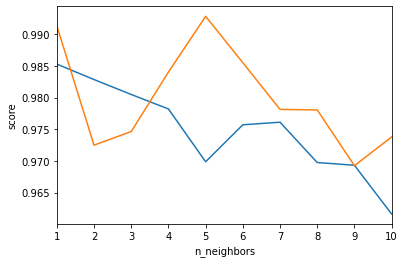

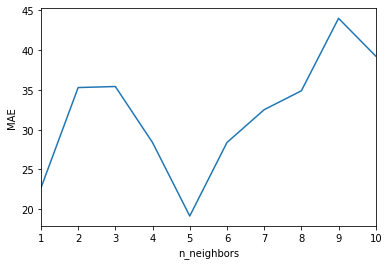

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error


# 농어 데이터
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])


# 주어진 데이터를 train과 test로 분리한다.

train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state=42)


# input 배열의 크기를 2차원 배열로 재조정한다.

train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)

# KNN 회귀로 농어의 무게를 예측
knr = KNeighborsRegressor()
nlist = [1,2,3,4,5,6,7,8,9,10] # 이웃한 개수 list
train_score = []
test_score = []
mae = []

# 이웃한 개수 1~10 까지 train set과 test set의 점수 비교하기
for n in range(1,11):
    knr.n_neighbors = n # 이웃한 개수 설정
    knr.fit(train_input, train_target) # 훈련

  # test set에 대한 예측값
    test_prediction = knr.predict(test_input)

  # test set에 대한 평균 절댓값 오차
    mae.append(mean_absolute_error(test_target, test_prediction))

  # train, test 점수
    train_score.append(knr.score(train_input, train_target)) # 훈련 세트 점수
    test_score.append(knr.score(test_input, test_target)) # 테스트 세트 점수

# 훈련 세트와 테스트 세트 그래프 그리기

plt.plot(nlist, train_score, label='Train Score')
plt.plot(nlist, test_score, label='Test Score')

plt.xlim((1,10))
plt.xlabel("n_neighbors")
plt.ylabel("score")
plt.show()

# MAE 그래프 그리기

plt.plot(nlist, mae)

plt.xlim((1,10))
plt.xlabel("n_neighbors")
plt.ylabel("MAE")
plt.show()

## 문제4

1주차 실습 문제에서 사용한 fish_csv의 FISH_DATA를 이용한 Weight을 예측하는 문제입니다.(Multiple Regression,Ridge Regression 활용)

**1단계:'fish_data와 weight 데이터 추출하기**

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
drive.mount('/content/drive')
data_path = '/content/SAI/Fish.csv'
df = pd.read_csv(data_path)
df
## data에 'Length1','Length2','Length3','Height','Width' 정보를 추출
fish_data = df[['Length1','Length2','Length3','Height','Width']]
fish_data
## target으로 weight을 추출.
fish_weight = df[['Weight']]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2단계:fish_data,fish_Weight을 활용한 multipleRegression**

In [ ]:
from sklearn.model_selection import  train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
train_input,test_input,train_target,test_target=train_test_split(fish_data,fish_weight,random_state=42) # 훈련 데이터와 테스트 데이터 분리

##degree1,2,3중 가장 훈련세트에 대해서 점수가 높은 degree를 구해서 훈련시키고 점수를 구하는 코드를 완성!

poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

lr=LinearRegression()   #모델 구성

lr.fit(train_poly, train_target)    #모델 학습

print(lr.score(train_poly,train_target))
print(lr.score(test_poly,test_target))


0.9855363403643641
0.9682828269737904


##문제5

**3단계: 정규화와와 릿지 회귀**

0.9889315122774638
0.9723714130285396


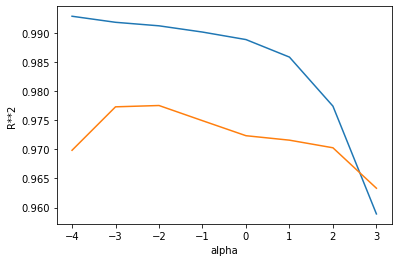

0.9588986366779707
0.9633263838163665


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

###degree 5일 때는 테스트 세트 점수가 음수임.->이 때의 문제점을 릿지 회귀로 해결.
poly=PolynomialFeatures(degree=5,include_bias=False)
poly.fit(train_input)
train_poly=poly.transform(train_input)
test_poly=poly.transform(test_input)

###정규화를 먼저 진행.
ss=StandardScaler()
ss.fit(train_poly)
train_scaled=ss.transform(train_poly)
test_scaled=ss.transform(test_poly)
ridge=Ridge()
ridge.fit(train_scaled,train_target)
print(ridge.score(train_scaled,train_target))
print(ridge.score(test_scaled,test_target))
train_score=[]
test_score=[]

##가장 최적화된 alpha계수를 구하고, 이 계수를 적용하여, 점수를 출력.
alpha_list=[0.0001,0.001,0.01,0.1,1,10,100,1000]
for alpha in alpha_list:
  ridge=Ridge(alpha)
  ridge.fit(train_scaled,train_target)
  train_score.append(ridge.score(train_scaled,train_target))
  test_score.append(ridge.score(test_scaled,test_target))
plt.plot(np.log10(alpha_list),train_score)
plt.plot(np.log10(alpha_list),test_score)
plt.xlabel('alpha')
plt.ylabel('R**2')
plt.show()
#ridge=Ridge(alpha=)
#ridge.fit()
print(ridge.score(train_scaled,train_target))
print(ridge.score(test_scaled,test_target))